<a href="https://colab.research.google.com/github/kyungeunvoyage/MotionDualAxisVib/blob/main/(final)accuracy_and_dprime_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Study — Condition Accuracy (Wilson CI) & d′ Heatmap
Data aggregated across P01–P05. Accuracy is collapsed across waveforms within each (side × axis). d′ is computed within-axis (Forward vs Backward on Y; Up vs Down on Z) per waveform and (side × axis), using log-linear correction.

In [3]:
!pip -q install statsmodels pingouin
from google.colab import drive; drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.2 MB/s eta 0:00:00
Mounted at /content/drive


In [4]:
import pandas as pd, numpy as np, glob
from pathlib import Path

In [5]:
DATA_DIR = "/content/drive/MyDrive/2026 Haptics Symposium/00.Exploratory Study/Experiment Data"

import os, glob, pandas as pd

os.chdir(DATA_DIR)

In [6]:
paths = sorted(glob.glob("P*_exploratory_raw.csv"))
dfs = []
for p in paths:
    df = pd.read_csv(p)
    df['participant'] = Path(p).stem.split('_')[0]
    dfs.append(df)
all_df = pd.concat(dfs, ignore_index=True)
# Standardize
all_df['side'] = all_df['side'].astype(str).str.strip().str.lower().map({'ulnar':'ulnar','radial':'radial'}).fillna('')
all_df['axis'] = all_df['axis'].astype(str).str.strip().str.upper()
all_df['waveform'] = pd.to_numeric(all_df['waveform'], errors='coerce').astype('Int64')
# Filter to valid side/axis rows
valid = all_df['side'].isin(['ulnar','radial']) & all_df['axis'].isin(['Y','Z'])
df_valid = all_df.loc[valid].copy()
df_valid['correct'] = pd.to_numeric(df_valid['correct'], errors='coerce').fillna(0).astype(int)
df_valid.head()

,timestamp,participant_id,session_no,block,side,axis,waveform,sign,true_dir,true_label,...,correct,rt_ms,confidence,play_count,total_pulses,code,side_byte,demo_mode,notes,participant
0,2025-08-29T06:09:51.107Z,P01,1,A,ulnar,Y,5,1,1,Forward,...,0,6021,4,3,3,8,0,0,NaN,P01
1,2025-08-29T06:10:28.548Z,P01,1,A,radial,Z,6,1,1,Up,...,1,4208,5,8,8,10,1,0,NaN,P01
2,2025-08-29T06:10:38.016Z,P01,1,A,ulnar,Y,3,1,1,Forward,...,0,4860,5,3,3,4,0,0,NaN,P01
3,2025-08-29T06:11:16.240Z,P01,1,A,radial,Z,2,1,1,Up,...,0,19694,4,6,6,2,1,0,NaN,P01
4,2025-08-29T06:11:25.790Z,P01,1,A,ulnar,Y,2,1,1,Forward,...,0,5964,5,2,2,2,0,0,NaN,P01


In [7]:
import numpy as np, pandas as pd, math
def wilson_ci(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2/(2*n)) / denom
    margin = (z * ((phat*(1-phat) + z**2/(4*n))/n) ** 0.5) / denom
    return (center - margin, center + margin)

grp = df_valid.groupby(['side','axis'])['correct']
acc_tbl = grp.agg(n='count', correct_sum='sum')
acc_tbl['accuracy'] = acc_tbl['correct_sum'] / acc_tbl['n']
cis = acc_tbl.apply(lambda r: pd.Series(wilson_ci(r['correct_sum'], r['n']), index=['ci_low','ci_high']), axis=1)
acc_tbl = pd.concat([acc_tbl, cis], axis=1).reset_index().sort_values(['side','axis']).reset_index(drop=True)
acc_tbl

,side,axis,n,correct_sum,accuracy,ci_low,ci_high
0,radial,Y,960,455,0.473958,0.442539,0.505586
1,radial,Z,960,424,0.441667,0.410548,0.473251
2,ulnar,Y,960,476,0.495833,0.464285,0.527415
3,ulnar,Z,960,442,0.460417,0.429107,0.492042


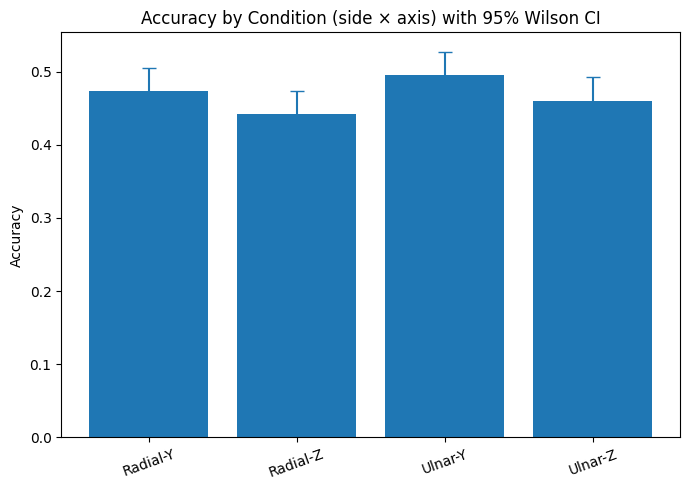

In [8]:
import matplotlib.pyplot as plt, numpy as np
plt.figure(figsize=(7,5))
x_labels = [f"{s.capitalize()}-{a}" for s,a in zip(acc_tbl['side'], acc_tbl['axis'])]
y = acc_tbl['accuracy'].values
yerr = np.vstack([acc_tbl['accuracy']-acc_tbl['ci_low'], acc_tbl['ci_high']-acc_tbl['accuracy']])
plt.bar(x_labels, y)
plt.errorbar(x_labels, y, yerr=yerr, fmt='none', capsize=5)
plt.ylabel('Accuracy')
plt.title('Accuracy by Condition (side × axis) with 95% Wilson CI')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [9]:
import math, numpy as np, pandas as pd
def norm_ppf(p):
    try:
        from scipy.stats import norm
        return norm.ppf(p)
    except Exception:
        # Acklam approximation
        a1=-39.69683028665376; a2=220.9460984245205; a3=-275.9285104469687
        a4=138.3577518672690; a5=-30.66479806614716; a6=2.506628277459239
        b1=-54.47609879822406; b2=161.5858368580409; b3=-155.6989798598866
        b4=66.80131188771972; b5=-13.28068155288572
        c1=-7.784894002430293e-03; c2=-0.3223964580411365
        c3=-2.400758277161838; c4=-2.549732539343734
        c5=4.374664141464968; c6=2.938163982698783
        d1=7.784695709041462e-03; d2=0.3224671290700398
        d3=2.445134137142996; d4=3.754408661907416
        plow=0.02425; phigh=1-plow
        if p < plow:
            q = math.sqrt(-2*math.log(p))
            return (((((c1*q+c2)*q+c3)*q+c4)*q+c5)*q+c6)/((((d1*q+d2)*q+d3)*q+d4)*q+1)
        elif p <= phigh:
            q = p-0.5; r=q*q
            return (((((a1*r+a2)*r+a3)*r+a4)*r+a5)*r+a6)*q/((((((b1*r+b2)*r+b3)*r+b4)*r+b5)*r)+1)
        else:
            q = math.sqrt(-2*math.log(1-p))
            return -(((((c1*q+c2)*q+c3)*q+c4)*q+c5)*q+c6)/((((d1*q+d2)*q+d3)*q+d4)*q+1)

def dprime_from_counts(hits, sig_n, fas, noise_n):
    if sig_n<=0 or noise_n<=0: return np.nan
    H = (hits + 0.5) / (sig_n + 1)
    F = (fas + 0.5) / (noise_n + 1)
    H = min(max(H, 1e-6), 1-1e-6)
    F = min(max(F, 1e-6), 1-1e-6)
    return norm_ppf(H) - norm_ppf(F)

def compute_axis_dprime(subdf):
    tl = subdf['true_label'].astype(str).str.lower()
    rl = subdf['response_label'].astype(str).str.lower()
    axis = subdf['axis'].iloc[0]
    if axis == 'Y':
        sig_mask = tl=='forward'; noise_mask = tl=='backward'; resp_sig = rl=='forward'
    elif axis == 'Z':
        sig_mask = tl.isin(['up','upward','upwards']);
        if not sig_mask.any(): sig_mask = tl=='up'
        noise_mask = tl.isin(['down','downward','downwards']); resp_sig = rl.isin(['up','upward','upwards'])
    else:
        return np.nan
    hits = int((sig_mask & resp_sig).sum()); sig_n = int(sig_mask.sum())
    fas = int((noise_mask & resp_sig).sum()); noise_n = int(noise_mask.sum())
    return dprime_from_counts(hits, sig_n, fas, noise_n)

group_cols = ['waveform','side','axis']
rows=[]
for keys, sub in df_valid.groupby(group_cols):
    rows.append((*keys, compute_axis_dprime(sub.copy())))
dprime_df = pd.DataFrame(rows, columns=group_cols+['dprime']).sort_values(group_cols).reset_index(drop=True)
dprime_df['col'] = dprime_df['side'].str.capitalize() + '-' + dprime_df['axis'].str.upper()
heat = dprime_df.pivot(index='waveform', columns='col', values='dprime').sort_index()
heat

col,Radial-Y,Radial-Z,Ulnar-Y,Ulnar-Z
waveform,,,,
1,0.098132,-0.040405,0.303671,-0.459906
2,-0.272831,0.085986,-0.144594,0.138879
3,0.400033,0.162797,0.126649,0.076232
4,-0.044456,-0.104766,-0.054774,0.076960
5,-0.093245,-0.628950,0.183901,-0.096621
6,0.166290,-0.047362,0.289824,-0.021035


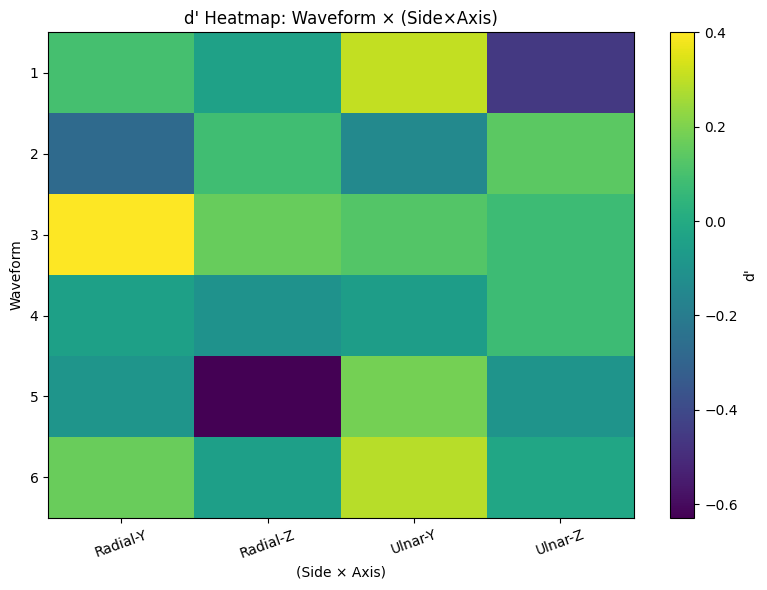

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.imshow(heat.values, aspect='auto'); plt.colorbar(label="d'")
plt.xticks(range(heat.shape[1]), heat.columns, rotation=20)
plt.yticks(range(heat.shape[0]), heat.index)
plt.title("d' Heatmap: Waveform × (Side×Axis)"); plt.xlabel('(Side × Axis)'); plt.ylabel('Waveform')
plt.tight_layout(); plt.show()

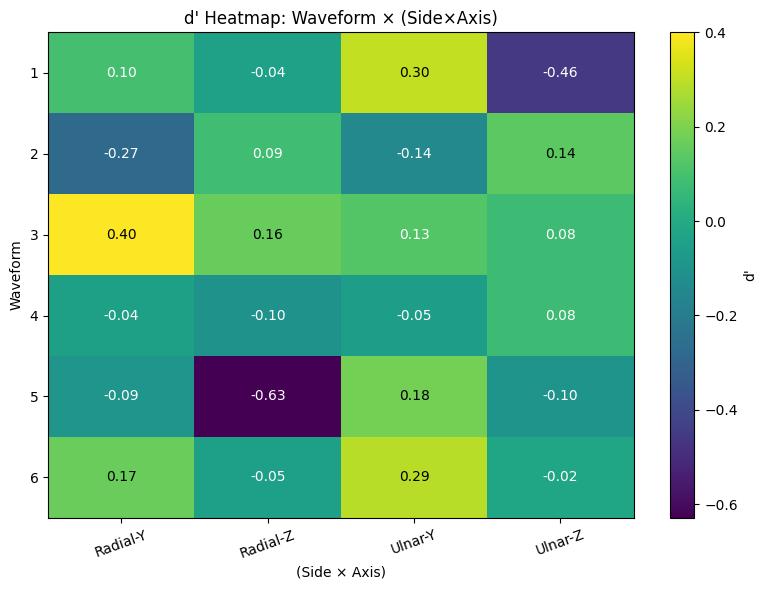

In [11]:
plt.figure(figsize=(8, 6))

# imshow에 넣을 2D 배열
M = heat.values

# 대칭 컬러스케일(선택): 양/음 d' 비교가 쉬워짐
# vabs = np.nanmax(np.abs(M))
# im = plt.imshow(M, aspect='auto', vmin=-vabs, vmax=vabs)
im = plt.imshow(M, aspect='auto')  # 대칭 원치 않으면 이 줄 사용

# 컬러바
cbar = plt.colorbar(im, label="d'")

# 축 라벨
plt.xticks(ticks=np.arange(heat.shape[1]), labels=heat.columns, rotation=20)
plt.yticks(ticks=np.arange(heat.shape[0]), labels=heat.index)
plt.title("d' Heatmap: Waveform × (Side×Axis)")
plt.xlabel("(Side × Axis)")
plt.ylabel("Waveform")


n_rows, n_cols = M.shape
for i in range(n_rows):
    for j in range(n_cols):
        val = M[i, j]
        if np.isnan(val):
            txt = "–"
        else:
            txt = f"{val:.2f}"
        # 대비를 위해 셀 배경 밝기 기준으로 글자색 자동 선택(옵션)
        # 픽셀 컬러를 얻어와서 밝기 계산
        rgba = im.cmap(im.norm(val if not np.isnan(val) else 0.0))
        # 가중 평균으로 대략적인 밝기 추정
        brightness = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
        color = "black" if brightness > 0.6 else "white"
        plt.text(j, i, txt, ha='center', va='center', fontsize=10, color=color)

plt.tight_layout()
plt.show()